# Bag of Words & Logistic Regression Classifier Baseline

In [1]:
import csv
import random

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
languages = ['af', 'de', 'en', 'es', 'fr', 'id', 'it', 'nl', 'pt', 'sv', 'tl', 'tr']

In [3]:
# Load the train, test, validation data
train_dataset = []
test_dataset = []
validation_dataset = []

train_path = f"dataset/train.csv"
with open(train_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        train_dataset.append(row)

    random.shuffle(train_dataset)
    train_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in train_dataset]
    
test_path = f"dataset/test.csv"
with open(test_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_dataset.append(row)

    random.shuffle(test_dataset)
    test_dataset = [{'id': item['id'], 'text': item['text']} for item in test_dataset]

validation_path = f"dataset/validation.csv"
with open(validation_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        validation_dataset.append(row)

    random.shuffle(validation_dataset)
    validation_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in validation_dataset]

## Visualizing the data

In [4]:
# Visualize the training dataset
print("Sample training data:")
train_df = pd.DataFrame(train_dataset)
train_df.head(10)

Sample training data:


,id,text,lang
0,5798,iphone,de
1,1362,allumer la prise,fr
2,3729,je veux entendre je t'aime de lara fabian pouv...,fr
3,11613,welke honkbalwedstrijden zijn gepland voor dez...,nl
4,51,alexa opciones de entrega mejor valoradas de c...,es
5,16852,nuove emaiò,it
6,1711,bewaar oerend hard liedje in mijn afspeellijst,nl
7,8950,hanapin ang natitira at tanggalin,tl
8,5979,zeig mir die uhrzeit in new york city,de
9,12733,waar is het dichtstbijzijnde treinstation,nl


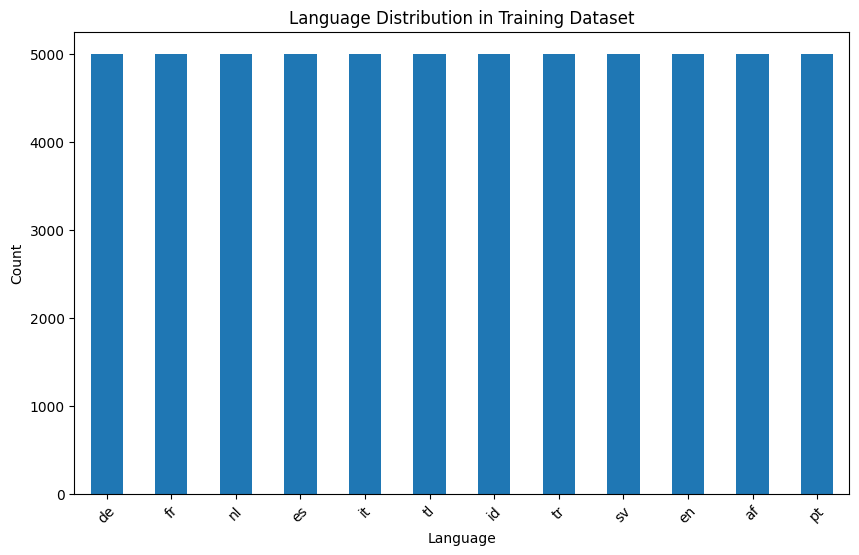

In [5]:
plt.figure(figsize=(10, 6))
train_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Training Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Visualize the test dataset
print("Sample test data:")
test_df = pd.DataFrame(test_dataset)
test_df.head(10)

Sample test data:


,id,text
0,4375,revoir toutes les alarmes
1,5225,que fecha es el próximo miercoles
2,3077,ausmachen der steckdose
3,2983,alarm verwijderen
4,14658,vad är växelkursen för euro och dollar
5,9408,avvia la riproduzione della radio
6,12957,definiere durchdacht
7,1803,prömiyer lig de bugün hangi takımlar oynuyor
8,11563,que puedo hacer en berlin
9,3193,tasa cinco


In [7]:
# Visualize the validation dataset
print("Sample validation data:")
validation_df = pd.DataFrame(validation_dataset)
validation_df.head(10)

Sample validation data:


,id,text,lang
0,6422,wikipedia onderwerpen,nl
1,1687,é um sim ou um não que a temperatura de amanhã...,pt
2,11084,ta bort mjölken från shoppinglistan,sv
3,5064,vervang die kleur van lig na donker,af
4,58,encontrar mi comida para llevar tailandesa alr...,es
5,7571,quando è il ciclo di bollette,it
6,9982,olly como hago ensaladilla,es
7,14269,quanto vale un euro in dollari,it
8,11364,vai al prossimo podcast,it
9,4840,play uptown girl by billy joel,en


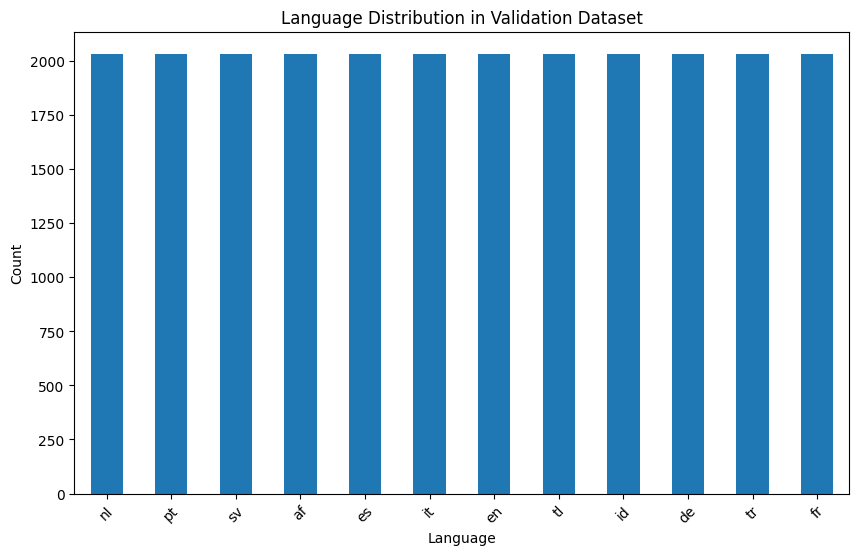

In [8]:
plt.figure(figsize=(10, 6))
validation_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Validation Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Model Training

In [9]:
# Split the data into features and labels
X_train = [item['text'] for item in train_dataset]
y_train = [item['lang'] for item in train_dataset]

X_test = [item['text'] for item in test_dataset]

X_val = [item['text'] for item in validation_dataset]
y_val = [item['lang'] for item in validation_dataset]

In [14]:
# Baseline prediction: Randomly assign a language label to each test sample
def baseline_predict(test_data):
    predictions = []
    for _ in test_data:
        label = random.choice(languages)
        predictions.append(label)
    return predictions

## Model Evaluation

In [15]:
y_pred = baseline_predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')

print(f"Accuracy: {accuracy*100:.4f}%")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 8.1407%
F1 Score: 0.0814

Classification Report:
              precision    recall  f1-score   support

          af       0.07      0.07      0.07      2033
          de       0.09      0.09      0.09      2033
          en       0.08      0.08      0.08      2033
          es       0.08      0.08      0.08      2033
          fr       0.09      0.09      0.09      2033
          id       0.09      0.09      0.09      2033
          it       0.09      0.09      0.09      2033
          nl       0.08      0.08      0.08      2033
          pt       0.07      0.07      0.07      2033
          sv       0.08      0.08      0.08      2033
          tl       0.08      0.08      0.08      2033
          tr       0.09      0.09      0.09      2033

    accuracy                           0.08     24396
   macro avg       0.08      0.08      0.08     24396
weighted avg       0.08      0.08      0.08     24396



In [17]:
# Run your prediction on the test set and save the results to a CSV file
y_test_pred = baseline_predict(test_dataset)

output_df = pd.DataFrame({'id': [item['id'] for item in test_dataset], 'lang': y_test_pred})
output_df.to_csv('prediction_results.csv', index=False)